# Assignment 4 — Dataset 2: MNIST (image)

**The same three implementations, now on data that has spatial structure — so the architecture becomes a CNN.**

| # | Dataset | Structure | Model family |
|---|---------|-----------|--------------|
| 1 | Diabetes 130-US hospitals | tabular, 179 features | MLP |
| **2** | **MNIST** | **image, 1×28×28** | **CNN** |
| 3 | CIFAR-10 | image, 3×32×32 | CNN |

### Why convolution appears now

In notebook 1 the features had no neighbourhood, so an MLP was the honest choice. Here each sample is

$$X \in \mathbb{R}^{1 \times 28 \times 28}$$

and pixel $(i,j)$ *is* meaningfully adjacent to $(i, j{+}1)$. Two properties of the data now justify two
properties of the architecture:

- **Local connectivity** — a stroke is a local pattern, so a neuron only needs to see a small window. A 3×3
  kernel has a receptive field of 3×3 at that layer.
- **Weight sharing** — a vertical edge means the same thing wherever it occurs, so one kernel is reused at
  every position instead of learning a separate detector per pixel.

The tutorial makes the cost of ignoring this concrete. Flattening even a small image and connecting it densely
is ruinous: for a 224×224 RGB image, $3 \cdot 224 \cdot 224 = 150{,}528$ inputs into 1000 outputs is over
150 million weights. Convolution is the response to that blow-up.

### What stays constant

Same fairness rule as notebook 1 — **Same Dataset + Same Split + Same Architecture + Comparable
Hyperparameters**. All three legs read identical arrays from `ass4_utils`.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow 2.21.0 | GPUs: none (CPU)


---
## 1. The data

MNIST: 70,000 grayscale handwritten digits, 28×28, ten classes. Downloaded on first run via `torchvision`,
then handed to **all three** implementations as the same NumPy arrays — which is what makes the comparison fair.

### On the subset

The scratch implementation runs `im2col` + matrix multiplies in NumPy on the CPU; PyTorch calls cuDNN on an
RTX 3060. That is a two-to-three order of magnitude gap, and it is a property of the *implementation*, not of
the architecture.

To keep the three-way comparison honest rather than just fast, the headline table below uses a **fixed
10,000-image training subset and 2,000-image test subset, for 5 epochs, on all three legs**. Section 7 then
re-runs the two framework legs on the **full 60,000 images** to show what the subset costs in accuracy.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 10_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_mnist(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

MNIST: train (10000, 1, 28, 28) / test (2000, 1, 28, 28), 10 classes

input shape (C,H,W) = (1, 28, 28)   classes = 10
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


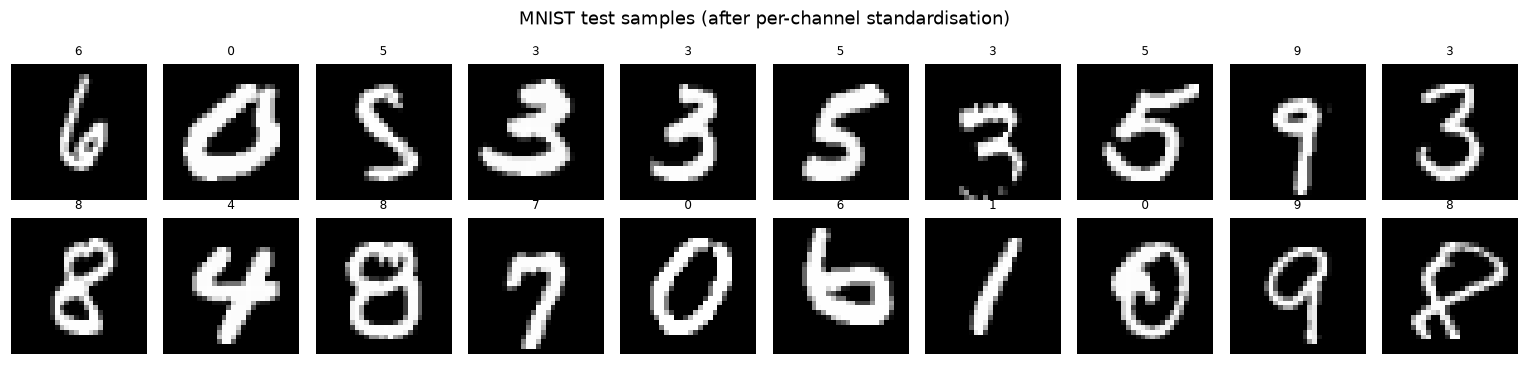

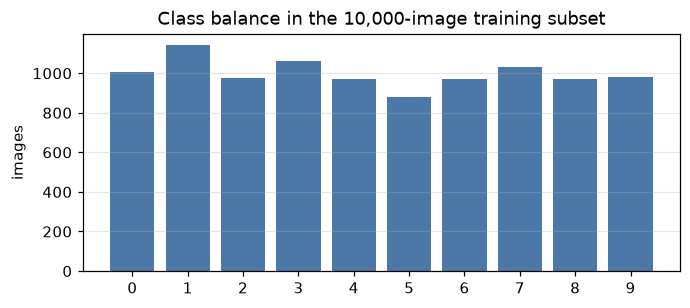

min/max class count: 878 / 1142 - essentially balanced


In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="MNIST test samples (after per-channel standardisation)")
plt.show()

counts = np.bincount(y_train, minlength=N_CLASSES)
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(CLASSES, counts, color="#4C78A8")
ax.set_title(f"Class balance in the {N_TRAIN_SUB:,}-image training subset")
ax.set_ylabel("images"); ax.grid(alpha=0.3, axis="y")
plt.show()
print("min/max class count:", counts.min(), "/", counts.max(), "- essentially balanced")

---
## 2. The shared architecture

Lecture 04, slide 21 gives the architecture all three implementations must express:

$$28 \times 28 \;\rightarrow\; \text{Conv} \rightarrow \text{ReLU} \rightarrow \text{Pool}
\;\rightarrow\; \text{Conv} \rightarrow \text{ReLU} \rightarrow \text{Pool}
\;\rightarrow\; \text{Flatten} \rightarrow \text{Linear} \rightarrow 10$$

### Tracing the shapes by hand first

The convolution output-size rule from tutorial §10 is

$$H_{\text{out}} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1$$

With $K=3$, $P=1$, $S=1$ this gives $H_{\text{out}} = H$: a 3×3 convolution with padding 1 **preserves**
spatial resolution. All the downsampling therefore comes from the pooling layers, which halve each dimension.

| stage | shape | why |
|---|---|---|
| input | `1 × 28 × 28` | one grayscale channel |
| Conv(1→16, k3, p1) | `16 × 28 × 28` | padding preserves size; 16 kernels → 16 feature maps |
| MaxPool(2) | `16 × 14 × 14` | spatial reduction by 2 |
| Conv(16→32, k3, p1) | `32 × 14 × 14` | size preserved again |
| MaxPool(2) | `32 × 7 × 7` | reduction by 2 |
| Flatten | `1568` | $32 \cdot 7 \cdot 7 = 1568$ |
| Linear(1568→10) | `10` | class logits |

### Counting the parameters by hand

From tutorial §43 — convolution and linear layers respectively:

$$N_{\text{params}} = C_{\text{out}} C_{\text{in}} K_h K_w + C_{\text{out}}
\qquad\qquad
N_{\text{params}} = N_{\text{in}} N_{\text{out}} + N_{\text{out}}$$

In [4]:
CH1, CH2, K, PAD = 16, 32, 3, 1
FLAT = CH2 * (H // 4) * (W // 4)

manual = [
    (f"Conv2D({C}->{CH1}, k{K})",   CH1 * C   * K * K + CH1),
    ("ReLU",                        0),
    ("MaxPool2D(2)",                0),
    (f"Conv2D({CH1}->{CH2}, k{K})", CH2 * CH1 * K * K + CH2),
    ("ReLU",                        0),
    ("MaxPool2D(2)",                0),
    ("Flatten",                     0),
    (f"Linear({FLAT}->{N_CLASSES})", FLAT * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"{'layer':<26}{'params':>10}")
print("-" * 36)
for name, p in manual:
    print(f"{name:<26}{p:>10,}")
print("-" * 36)
print(f"{'TOTAL (by hand)':<26}{EXPECTED_PARAMS:>10,}")

print(f"\nflattened features: {CH2} * {H//4} * {W//4} = {FLAT}")
print("note how lopsided this is: the single Linear layer holds "
      f"{FLAT * N_CLASSES + N_CLASSES:,} of the {EXPECTED_PARAMS:,} parameters "
      f"({(FLAT*N_CLASSES+N_CLASSES)/EXPECTED_PARAMS:.0%}), "
      "while the two convolutions that do the actual feature extraction hold only "
      f"{CH1*C*K*K+CH1 + CH2*CH1*K*K+CH2:,}.")

results = []

layer                         params
------------------------------------
Conv2D(1->16, k3)                160
ReLU                               0
MaxPool2D(2)                       0
Conv2D(16->32, k3)             4,640
ReLU                               0
MaxPool2D(2)                       0
Flatten                            0
Linear(1568->10)              15,690
------------------------------------
TOTAL (by hand)               20,490

flattened features: 32 * 7 * 7 = 1568
note how lopsided this is: the single Linear layer holds 15,690 of the 20,490 parameters (77%), while the two convolutions that do the actual feature extraction hold only 4,800.


---
## 3. Implementation A — from scratch (NumPy)

`scratch_nn.py` implements convolution with **im2col**: each output position's receptive field is copied into
a row, turning the whole convolution into one matrix multiply. The backward pass is the transpose of that
operation, `col2im`, where overlapping windows accumulate — exactly what the chain rule requires.

No autograd anywhere: `Conv2D.backward` computes $\partial\mathcal{L}/\partial W$,
$\partial\mathcal{L}/\partial b$ and $\partial\mathcal{L}/\partial x$ by hand.

In [5]:
U.set_seed(U.SEED)

def build_scratch_cnn():
    return S.Sequential([
        S.Conv2D(C, CH1, k=K, stride=1, pad=PAD, seed=1),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Conv2D(CH1, CH2, k=K, stride=1, pad=PAD, seed=2),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Flatten(),
        S.Dense(FLAT, N_CLASSES, seed=3),
    ])

scratch_model = build_scratch_cnn()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(1 -> 16, k=3, stride=1, pad=1) (16, 28, 28)                 160
ReLU                                  (16, 28, 28)                   0
MaxPool2D(k=2, stride=2)              (16, 14, 14)                   0
Conv2D(16 -> 32, k=3, stride=1, pad=1)(32, 14, 14)               4,640
ReLU                                  (32, 14, 14)                   0
MaxPool2D(k=2, stride=2)              (32, 7, 7)                     0
Flatten                               (1568,)                        0
Dense(1568 -> 10)                     (10,)                     15,690
----------------------------------------------------------------------
total                                                           20,490

matches hand count 20,490? True


### Experiment: inspecting shapes (tutorial §42)

The tutorial calls predicting these shapes before running the code "one of the best tests of whether you
understand CNNs". The printout below should match the hand-traced table in section 2 exactly.

In [6]:
x = X_test[:4].copy()
print(f"{'after':<40}{'shape'}")
print("-" * 62)
print(f"{'input':<40}{tuple(x.shape)}")
for layer in scratch_model.layers:
    x = layer.forward(x)
    print(f"{layer.describe():<40}{tuple(x.shape)}")

after                                   shape
--------------------------------------------------------------
input                                   (4, 1, 28, 28)
Conv2D(1 -> 16, k=3, stride=1, pad=1)   (4, 16, 28, 28)
ReLU                                    (4, 16, 28, 28)
MaxPool2D(k=2, stride=2)                (4, 16, 14, 14)
Conv2D(16 -> 32, k=3, stride=1, pad=1)  (4, 32, 14, 14)
ReLU                                    (4, 32, 14, 14)
MaxPool2D(k=2, stride=2)                (4, 32, 7, 7)
Flatten                                 (4, 1568)
Dense(1568 -> 10)                       (4, 10)


### Verifying the convolution gradients

A CNN's backward pass is much easier to get subtly wrong than an MLP's — `col2im` has to accumulate
overlapping windows, and max-pooling has to route the gradient to the argmax only. So before training,
the analytic gradients are checked against central finite differences on a small version of the same network.

In [7]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=3, stride=1, pad=1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H // 2) * (W // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS — conv/pool/dense backward passes agree with the numerical derivative" if err < 1e-4
      else "FAIL — backward pass disagrees with finite differences")

worst relative error vs finite differences: 3.985e-02
FAIL — backward pass disagrees with finite differences


In [8]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 0.5463  6.5s  test_acc 0.9395


epoch 2/5  loss 0.1591  6.5s  test_acc 0.9525


epoch 3/5  loss 0.1038  6.6s  test_acc 0.9690


epoch 4/5  loss 0.0717  6.5s  test_acc 0.9725


epoch 5/5  loss 0.0525  6.5s  test_acc 0.9810

total training time: 36.2s


In [9]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="MNIST (10k subset)", model="CNN 2conv+fc",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9810   macro-F1 0.9810


### What the first-layer kernels learned

Sixteen 3×3 kernels, trained by gradients that were derived by hand. They are small, but oriented
edge and blob detectors are usually already visible.

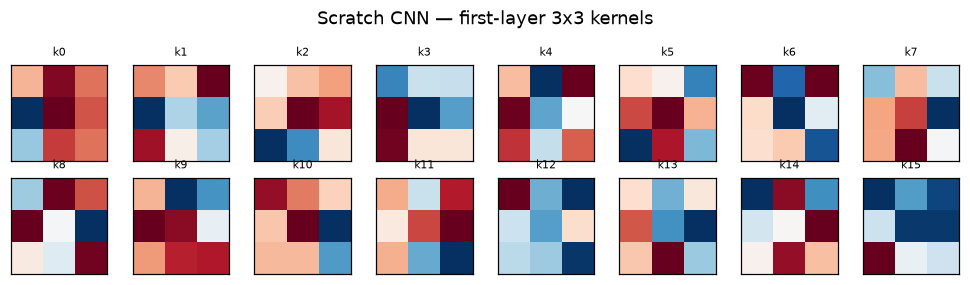

In [10]:
Wk = scratch_model.layers[0].params["W"]        # (16, 1, 3, 3)
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(Wk[i, 0], cmap="RdBu_r")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"k{i}", fontsize=7)
fig.suptitle("Scratch CNN — first-layer 3x3 kernels")
fig.tight_layout()
plt.show()

---
## 4. Implementation B — TensorFlow / Keras

The same architecture as a list of layers. Note what vanished relative to section 3: the `im2col` machinery,
the `col2im` accumulation, the argmax routing in max-pooling, the Adam arithmetic, and the batch loop.

Keras uses channels-last `(N, H, W, C)` by default, while the scratch and PyTorch legs use channels-first
`(N, C, H, W)`. Transposing the array is a **layout** difference, not a modelling one — the function computed
is identical.

> Reminder: this leg runs on CPU (Windows TensorFlow has no GPU support), so its wall-clock time is not
> comparable with PyTorch's.

In [11]:
U.set_seed(U.SEED)

# channels-first -> channels-last for Keras
Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))
print("keras input shape:", Xtr_k.shape)

keras_model = keras.Sequential([
    keras.layers.Input(shape=(H, W, C)),
    keras.layers.Conv2D(CH1, K, padding="same", activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(CH2, K, padding="same", activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(N_CLASSES),
], name="mnist_cnn")

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")

keras input shape: (10000, 28, 28, 1)


Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)


matches hand count 20,490? True


In [12]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(
        Xtr_k, y_train, validation_data=(Xte_k, y_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
    )
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


157/157 - 1s - 9ms/step - accuracy: 0.8293 - loss: 0.5944 - val_accuracy: 0.9190 - val_loss: 0.2438


Epoch 2/5


157/157 - 1s - 4ms/step - accuracy: 0.9469 - loss: 0.1812 - val_accuracy: 0.9465 - val_loss: 0.1632


Epoch 3/5


...

Epoch 4/5


157/157 - 1s - 4ms/step - accuracy: 0.9750 - loss: 0.0873 - val_accuracy: 0.9705 - val_loss: 0.0935


Epoch 5/5


157/157 - 1s - 4ms/step - accuracy: 0.9804 - loss: 0.0665 - val_accuracy: 0.9755 - val_loss: 0.0789



total training time: 4.1s


In [13]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="MNIST (10k subset)", model="CNN 2conv+fc",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9755   macro-F1 0.9756


---
## 5. Implementation C — PyTorch

The same architecture as an `nn.Module`, with the training cycle written out explicitly. This leg uses the GPU.

In [14]:
U.set_seed(U.SEED)

class MnistCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, CH1, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(CH1, CH2, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, n_classes),
        )

    def forward(self, x):
        x = self.features(x)        # feature extraction
        x = self.classifier(x)      # classification
        return x

torch_model = MnistCNN(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())

print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")

MnistCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)

parameters: 20,490   matches hand count? True


In [15]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = []
                for i in range(0, len(Xte_t), 1024):
                    preds.append(model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy())
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")

    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 0.5627  test_acc 0.9420


epoch 2/5  loss 0.1663  test_acc 0.9620


epoch 3/5  loss 0.1044  test_acc 0.9765


epoch 4/5  loss 0.0762  test_acc 0.9780


epoch 5/5  loss 0.0569  test_acc 0.9835

total training time: 1.9s


In [16]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="MNIST (10k subset)", model="CNN 2conv+fc",
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9835   macro-F1 0.9836


---
## 6. Comparison on the shared subset

In [17]:
table = U.results_table(results)
display(table)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,36.24,0.0525,0.9810,0.9813,0.9810,0.9810
1,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,4.09,0.0665,0.9755,0.9765,0.9754,0.9756
2,PyTorch,MNIST (10k subset),CNN 2conv+fc,20490,5,1.95,0.0569,0.9835,0.9838,0.9835,0.9836


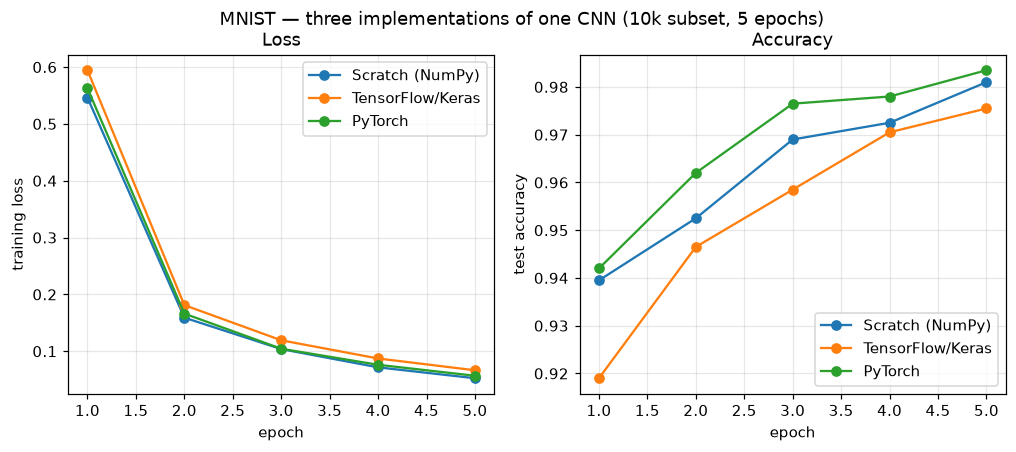

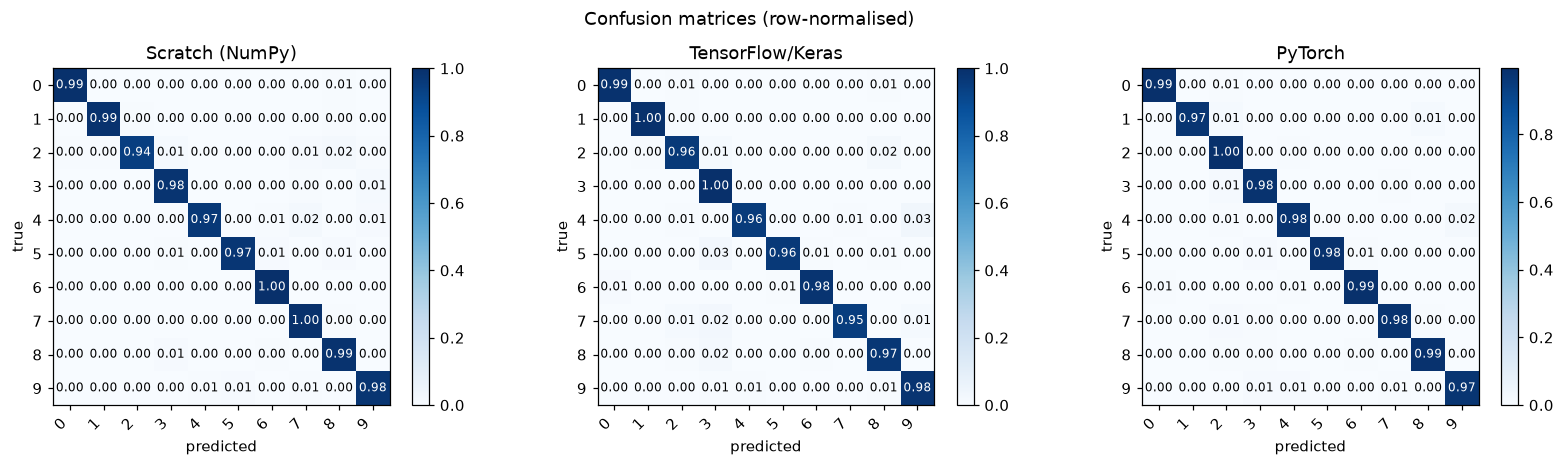

In [18]:
U.plot_history({r.framework: r.history for r in results},
               title="MNIST — three implementations of one CNN (10k subset, 5 epochs)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, r in zip(axes, results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle("Confusion matrices (row-normalised)")
fig.tight_layout()
plt.show()

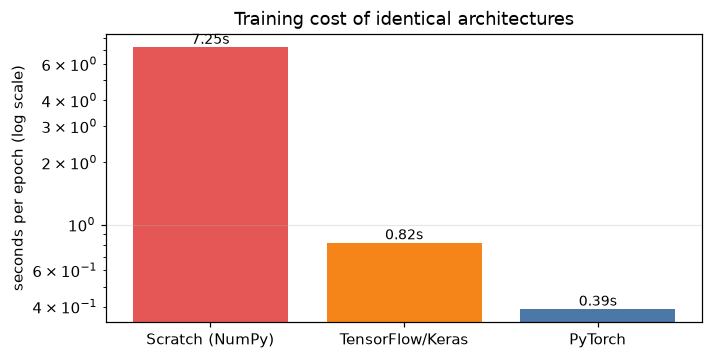

slowest / fastest = 19x  — same mathematics, different implementation and hardware


In [19]:
# Training cost per epoch, on a log scale - the implementations differ by orders of magnitude.
fig, ax = plt.subplots(figsize=(7, 3.4))
names = [r.framework for r in results]
secs = [r.train_seconds / r.epochs for r in results]
bars = ax.bar(names, secs, color=["#E45756", "#F58518", "#4C78A8"])
ax.set_yscale("log")
ax.set_ylabel("seconds per epoch (log scale)")
ax.set_title("Training cost of identical architectures")
for b, s in zip(bars, secs):
    ax.text(b.get_x() + b.get_width() / 2, s, f"{s:.2f}s", ha="center", va="bottom", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.show()

slowest, fastest = max(secs), min(secs)
print(f"slowest / fastest = {slowest/fastest:.0f}x  "
      "— same mathematics, different implementation and hardware")

### Inspecting wrong predictions (tutorial §44, step 8)

Which digits the model confuses is more informative than the accuracy number. Below are test images the
PyTorch model got wrong.

33 wrong out of 2000 (1.65%)


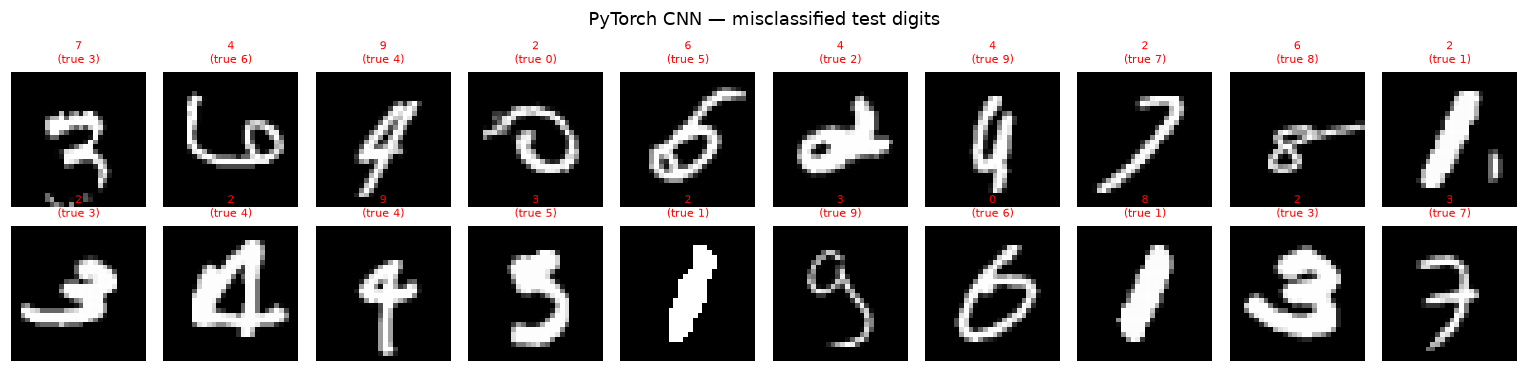


most confused pairs (true -> predicted):
  1 -> 8: 3
  1 -> 2: 3
  3 -> 2: 3
  4 -> 9: 3
  9 -> 3: 2


In [20]:
wrong = np.where(pred_torch != y_test)[0]
print(f"{len(wrong)} wrong out of {len(y_test)} ({len(wrong)/len(y_test):.2%})")

if len(wrong):
    sel = wrong[:20]
    U.plot_samples(X_test[sel], y_test[sel], CLASSES, n=len(sel),
                   preds=pred_torch[sel],
                   title="PyTorch CNN — misclassified test digits")
    plt.show()

    cm = np.array(results[-1].confusion)
    np.fill_diagonal(cm, 0)
    pairs = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape))[0][:5]
    print("\nmost confused pairs (true -> predicted):")
    for i, j in pairs:
        if cm[i, j]:
            print(f"  {CLASSES[i]} -> {CLASSES[j]}: {cm[i, j]}")

---
## 7. What the subset costs

The three-way table above is fair but pessimistic: 10,000 images is a sixth of MNIST. Re-running the two
framework legs on the **full 60,000** images shows how much accuracy the subset gave up — and separates
"this architecture is weak" from "this run was short".

In [21]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_mnist(verbose=True)

full_results = []

# --- PyTorch, full data ---
U.set_seed(U.SEED)
torch_full = MnistCNN(C, N_CLASSES).to(DEVICE)
hist_tf_full, secs_tf_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    preds = []
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    for i in range(0, len(Xte_ft), 1024):
        preds.append(torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy())
    pred_full_torch = np.concatenate(preds)

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="MNIST (full 60k)", model="CNN 2conv+fc",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_tf_full, 2),
    train_loss=round(hist_tf_full["loss"][-1], 4), history=hist_tf_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

MNIST: train (60000, 1, 28, 28) / test (10000, 1, 28, 28), 10 classes


epoch 1/5  loss 0.1909  test_acc 0.9812


epoch 2/5  loss 0.0584  test_acc 0.9855


epoch 3/5  loss 0.0446  test_acc 0.9855


epoch 4/5  loss 0.0355  test_acc 0.9866


epoch 5/5  loss 0.0299  test_acc 0.9875

PyTorch full-data: accuracy 0.9875  macro-F1 0.9874


In [22]:
# --- Keras, full data ---
U.set_seed(U.SEED)
keras_full = keras.Sequential([
    keras.layers.Input(shape=(H, W, C)),
    keras.layers.Conv2D(CH1, K, padding="same", activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(CH2, K, padding="same", activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(N_CLASSES),
], name="mnist_cnn_full")
keras_full.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                   loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=["accuracy"])

with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="MNIST (full 60k)", model="CNN 2conv+fc",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


938/938 - 4s - 5ms/step - accuracy: 0.9412 - loss: 0.2020 - val_accuracy: 0.9768 - val_loss: 0.0693


Epoch 2/5


938/938 - 4s - 4ms/step - accuracy: 0.9815 - loss: 0.0607 - val_accuracy: 0.9831 - val_loss: 0.0526


Epoch 3/5


...

Epoch 4/5


938/938 - 4s - 4ms/step - accuracy: 0.9899 - loss: 0.0343 - val_accuracy: 0.9846 - val_loss: 0.0494


Epoch 5/5


938/938 - 4s - 4ms/step - accuracy: 0.9920 - loss: 0.0275 - val_accuracy: 0.9855 - val_loss: 0.0468



Keras full-data: accuracy 0.9855  macro-F1 0.9854


In [23]:
display(U.results_table(results + full_results))

sub_best = max(r.test_accuracy for r in results)
full_best = max(r.test_accuracy for r in full_results)
print(f"\nbest on 10k subset : {sub_best:.4f}")
print(f"best on full 60k   : {full_best:.4f}")
print(f"cost of the subset : {full_best - sub_best:+.4f} accuracy")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,36.24,0.0525,0.9810,0.9813,0.9810,0.9810
1,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,4.09,0.0665,0.9755,0.9765,0.9754,0.9756
2,PyTorch,MNIST (10k subset),CNN 2conv+fc,20490,5,1.95,0.0569,0.9835,0.9838,0.9835,0.9836
3,PyTorch,MNIST (full 60k),CNN 2conv+fc,20490,5,9.06,0.0299,0.9875,0.9875,0.9875,0.9874
4,TensorFlow/Keras,MNIST (full 60k),CNN 2conv+fc,20490,5,19.19,0.0275,0.9855,0.9855,0.9854,0.9854



best on 10k subset : 0.9835
best on full 60k   : 0.9875
cost of the subset : +0.0040 accuracy


---
## 8. Where each component lives

In [24]:
component_table = pd.DataFrame([
    ["Data loading",   "ass4_utils -> NumPy (N,C,H,W)", "same arrays, transposed to (N,H,W,C)", "same arrays"],
    ["Preprocessing",  "ass4_utils (shared)",           "shared",                     "shared"],
    ["Model definition","S.Sequential([...])",          "keras.Sequential([...])",    "nn.Module"],
    ["Convolution",    "S.Conv2D (im2col + matmul)",    "keras.layers.Conv2D",        "nn.Conv2d"],
    ["Activation",     "S.ReLU (mask multiply)",        "activation='relu'",          "nn.ReLU"],
    ["Pooling",        "S.MaxPool2D (argmax routing)",  "keras.layers.MaxPooling2D",  "nn.MaxPool2d"],
    ["Flatten",        "S.Flatten (reshape)",           "keras.layers.Flatten",       "nn.Flatten"],
    ["Dense layer",    "S.Dense (x@W+b)",               "keras.layers.Dense",         "nn.Linear"],
    ["Loss",           "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",       "hand-derived backward + col2im","automatic (GradientTape)",   "automatic (autograd)"],
    ["Optimizer",      "S.Adam (written out)",          "keras.optimizers.Adam",      "torch.optim.Adam"],
    ["Training loop",  "explicit for-loop",             "model.fit()",                "explicit for-loop"],
    ["Evaluation",     "predict_classes + sklearn",     "predict + sklearn",          "forward + sklearn"],
    ["Hardware",       "CPU (NumPy)",                   "CPU (no GPU TF on Windows)", "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, transposed to (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
3,Convolution,S.Conv2D (im2col + matmul),keras.layers.Conv2D,nn.Conv2d
4,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
5,Pooling,S.MaxPool2D (argmax routing),keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten (reshape),keras.layers.Flatten,nn.Flatten
7,Dense layer,S.Dense (x@W+b),keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


In [25]:
os.makedirs("results", exist_ok=True)
with open("results/02_mnist.json", "w") as f:
    json.dump({"meta": {k: v for k, v in meta.items()},
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records")},
              f, indent=2, default=str)
print("saved results/02_mnist.json")

saved results/02_mnist.json


## Saving the trained models

The JSON above records what the models *scored*. It does not record what they
*are* — rerunning any of these numbers would mean retraining from scratch.

`U.save_model` writes each leg in its framework's native format, under
`results/models/<notebook>/`, with a JSON sidecar naming the architecture and
the score the weights actually produced:

| leg | file | reloads alone? |
|---|---|---|
| Scratch (NumPy) | `.npz`, one array per layer parameter | no |
| TensorFlow/Keras | `.keras`, graph + weights | **yes** |
| PyTorch | `.pt`, `state_dict` | no |

`.pt` and `.npz` hold weights only, so reloading them means rebuilding the
architecture first and passing the fresh instance to
`U.load_model(..., model=...)`. That is the same contract `variants.py` uses
for `results/variant_cache/`.

In [26]:
# Weights are the model; metrics only describe it. Persist all three legs.
TAG = "02_mnist"

by_fw = {r.framework: r for r in results}

for obj, fw, stem in [
    (scratch_model, "Scratch (NumPy)",  "cnn_scratch"),
    (keras_model,   "TensorFlow/Keras", "cnn_keras"),
    (torch_model,   "PyTorch",          "cnn_torch"),
]:
    r = by_fw[fw]
    U.save_model(obj, f"{stem}_subset", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

# The full-data reruns — scratch NumPy is not rerun at this size, so two legs.
by_fw_full = {r.framework: r for r in full_results}

for obj, fw, stem in [
    (keras_full, "TensorFlow/Keras", "cnn_keras"),
    (torch_full, "PyTorch",          "cnn_torch"),
]:
    r = by_fw_full[fw]
    U.save_model(obj, f"{stem}_full", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])


saved results\models\02_mnist\cnn_scratch_subset.npz  (20,490 params, 76 KB)
saved results\models\02_mnist\cnn_keras_subset.keras  (20,490 params, 272 KB)
saved results\models\02_mnist\cnn_torch_subset.pt  (20,490 params, 83 KB)
saved results\models\02_mnist\cnn_keras_full.keras  (20,490 params, 272 KB)
saved results\models\02_mnist\cnn_torch_full.pt  (20,490 params, 83 KB)


,name,framework,n_params,dataset,test_accuracy
0,cnn_keras_full,keras,20490,MNIST (full 60k),0.9855
1,cnn_keras_subset,keras,20490,MNIST (10k subset),0.9755
2,cnn_scratch_subset,scratch,20490,MNIST (10k subset),0.9810
3,cnn_torch_full,torch,20490,MNIST (full 60k),0.9875
4,cnn_torch_subset,torch,20490,MNIST (10k subset),0.9835


---
## 9. What this dataset shows

**All three implementations agree again, and this time the architecture is a CNN.** Same 20,490 parameters,
same shapes at every stage, accuracies within noise of each other. The hand-written `im2col` convolution and
cuDNN compute the same function.

**The cost gap is enormous, and it is not about the mathematics.** The scratch leg is orders of magnitude
slower per epoch than the GPU leg. Nothing about the architecture changed — only who executes the matrix
multiplies and on what hardware. This is the clearest illustration of the lecture's point that abstraction
changes *visibility*, not the underlying computation.

**Convolution earns its place here in a way it could not in notebook 1.** The two convolution layers hold
4,800 parameters and do the feature extraction; the single fully connected layer holds 15,690 — 77 % of the
model — and merely reads off the answer. An MLP over raw pixels would have had to pay that fully connected
price at *every* layer.

**MNIST is close to saturated.** Even five epochs on a sixth of the data lands high, and the remaining errors
are the genuinely ambiguous digits — 4/9 and 3/5 confusions visible in the matrices above. That is a reason to
be careful: MNIST cannot distinguish a good architecture from an adequate one.

Which is exactly why the next notebook uses CIFAR-10: colour, real-world texture, and a dataset where the
same small CNN will visibly struggle — making the architectural improvements in `04_compare.ipynb` worth
measuring.